# <h1 align="center"> Group 27 Final Project </h1>

<h1 align="center"> Livability for Pittsburgh neighborhood </h1>

<center> Designed by Zihan Yuan, Yuzhe Wang, Cortes-Del-Valle, Marcos F </center>

# Part1 Introduction

In this project, we aim to find the "best" neighborhood in Pittsburgh. We define our "bestness" as "livability" with tree aspects: safety, environment and convenience. we also define our submetric as "crime-scores with variable"x", tree-scores with variable "y" and convenient-scores with variable "z". Finally, we apply linear fumula ( f(x,y,z)=w1*x+w2*y+w3*z )with pre-defined weights w1, w2 and w3 for our final metric to determine the results.  we use 4 dataset for our analysis, the first one is the crime activities happened in the neighhood, the second one and third one are the number of trees in the neighborhood and the size for each neighbor, the last one is the number of transit stop in each neighhood.

# part2 The submetric analysis by using 4 dataset

## 1.analysis for the safety: crime_counts in each neighborhood (by Zihan)

In [1]:
!python -m pip install --upgrade pip


In [2]:
!pip install openpyxl

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel(r"C:\CMPINF\incidents_2024_thru_mar2026.xlsx")
df.head()

,Report_Number,ReportedDate,ReportedTime,Hour,DayofWeek,ReportedMonth,NIBRS_Coded_Offense,NIBRS_Offense_Code,NIBRS_Offense_Category,NIBRS_Offense_Type,NIBRS_Crime_Against,NIBRS_Offense_Grouping,Violation,XCOORD,YCOORD,Zone,Tract,Neighborhood,Block_Address
0,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13A AGGRAVATED ASSAULT,13A,Assault Offenses,Aggravated Assault,Person,A,18 2718 A1 Strangulation Basic - Applying,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
1,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13C INTIMIDATION,13C,Assault Offenses,Intimidation,Person,A,18 2706 A1 Terroristic Threats-General,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
2,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,90Z ALL OTHER OFFENSES,90Z,All other Offenses,All other Offenses,Group B,B,75 3733 A Fleeing or Attempting To Elude Polic...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
3,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,23H ALL OTHER LARCENY,23H,Larceny/Theft Offenses,All Other Larceny,Property,A,18 3921 A Theft by Unlawful Taking-Movable – L...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
4,PGHP24000017,2024-01-01,00:21,0,Monday,Jan,9999 Vehicle Offense (Not NIBRS Reportable),999,Not NIBRS Reportable,Not NIBRS Reportable,Group B,B,LO 6 101 Discharge of Firearms Prohibited,-80.0243,40.4582,Zone 1,2107,Manchester,"1200 Block of COLUMBUS AVE Pittsburgh, PA"


In [5]:
df.columns

Index(['Report_Number', 'ReportedDate', 'ReportedTime', 'Hour', 'DayofWeek',
       'ReportedMonth', 'NIBRS_Coded_Offense', 'NIBRS_Offense_Code',
       'NIBRS_Offense_Category', 'NIBRS_Offense_Type', 'NIBRS_Crime_Against',
       'NIBRS_Offense_Grouping', 'Violation', 'XCOORD', 'YCOORD', 'Zone',
       'Tract', 'Neighborhood', 'Block_Address'],
      dtype='object')

In [6]:
df = df.dropna(subset=['Neighborhood'])
df['Neighborhood'] = df['Neighborhood'].str.strip().str.lower()

In [7]:
crime_counts = df.groupby('Neighborhood').size().reset_index(name='crime_count')

In [8]:
crime_counts = crime_counts.sort_values(by='crime_count', ascending=True)

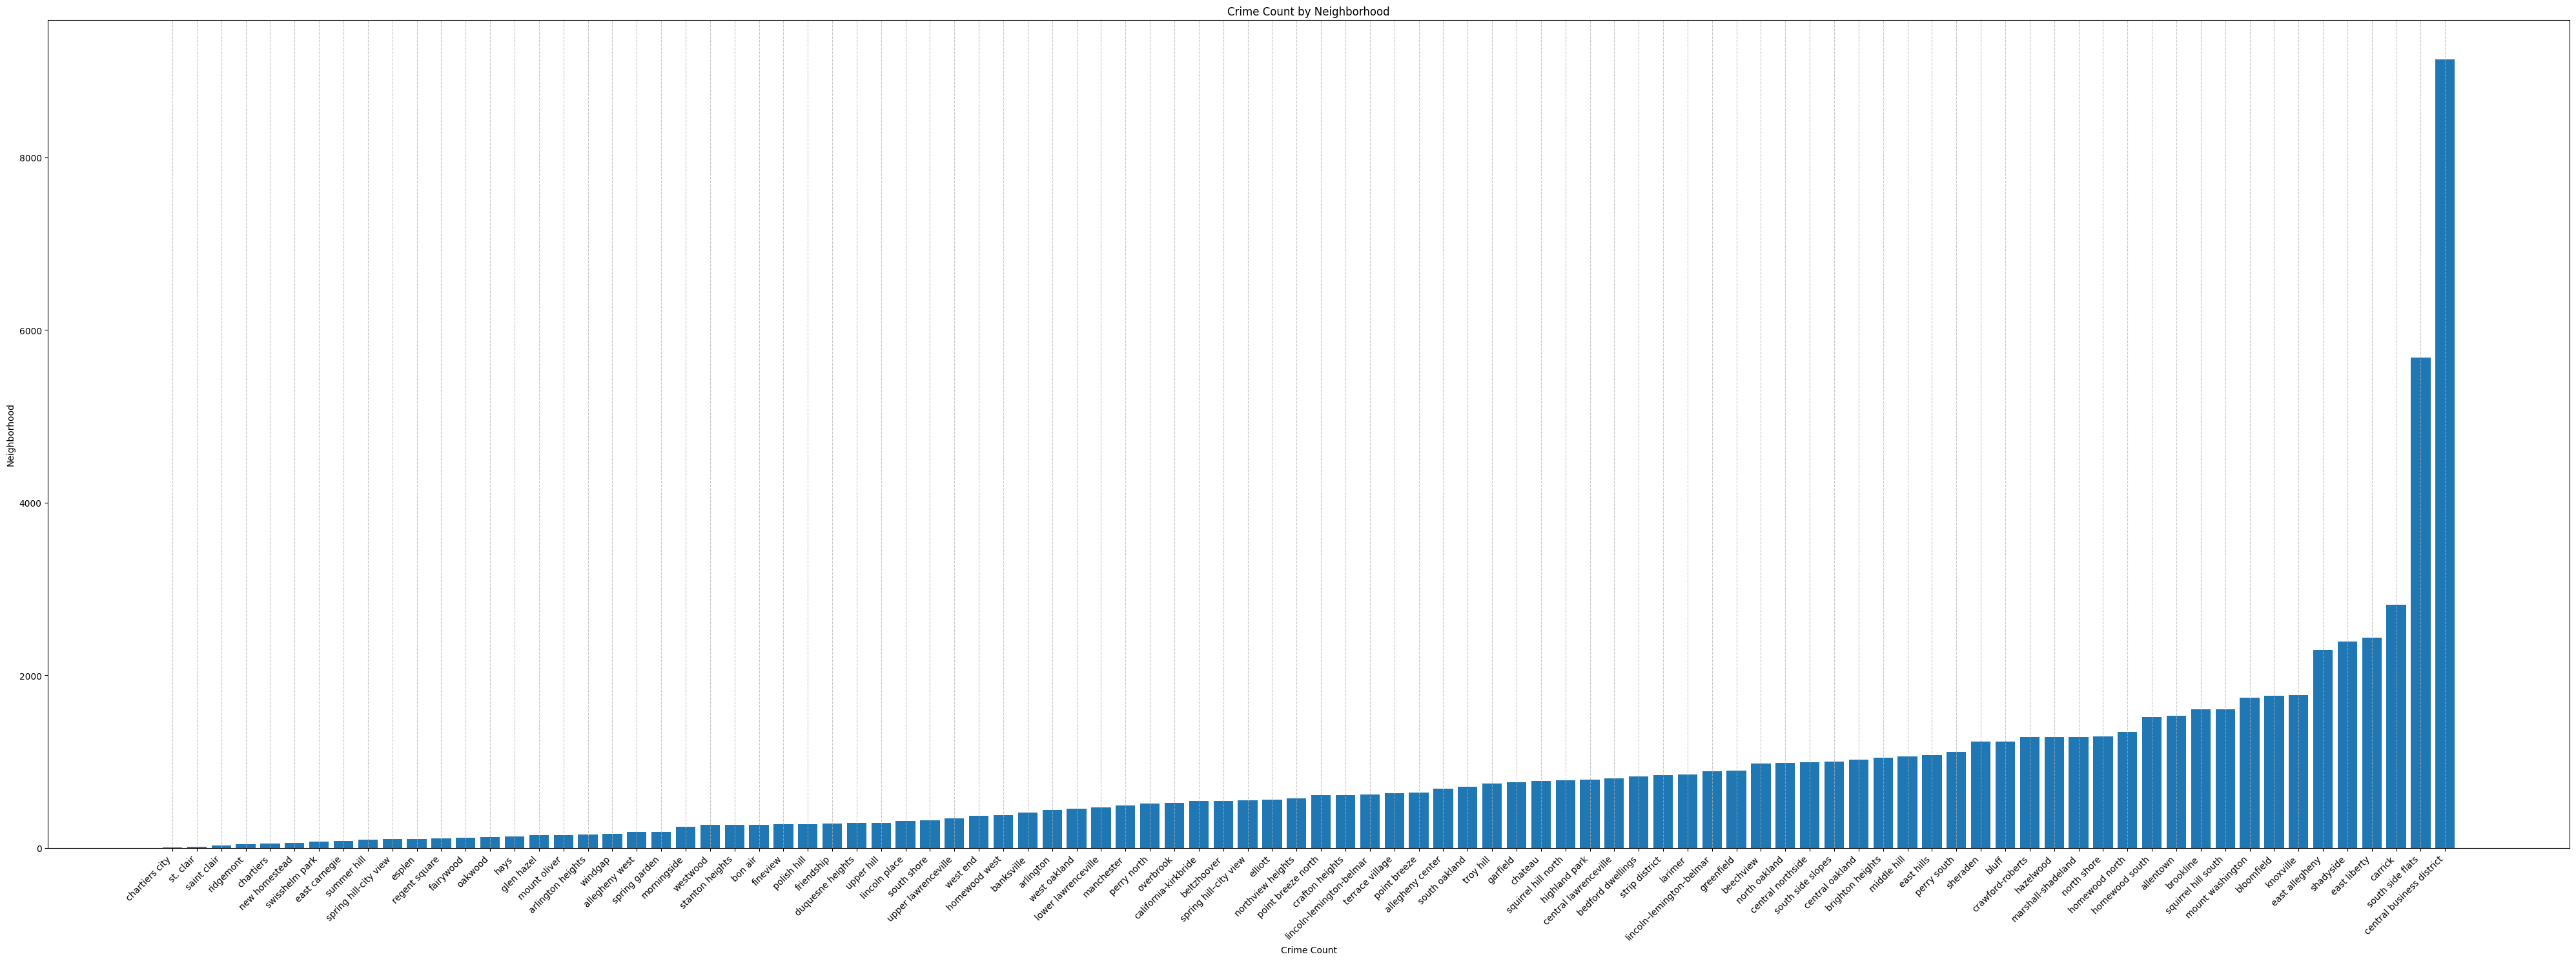

In [9]:
plt.figure(figsize=(40, 15))
plt.bar(
    crime_counts['Neighborhood'],
    crime_counts['crime_count']
)

plt.xlabel('Crime Count')
plt.ylabel('Neighborhood')
plt.title('Crime Count by Neighborhood')
plt.xticks( rotation=45,
     ha="right")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [10]:
crime_counts['crime_score'] = (
    crime_counts['crime_count'].max() - crime_counts['crime_count']
) / (
    crime_counts['crime_count'].max() - crime_counts['crime_count'].min()
)
crime_counts_sorted = crime_counts.sort_values(by='crime_score', ascending=False)

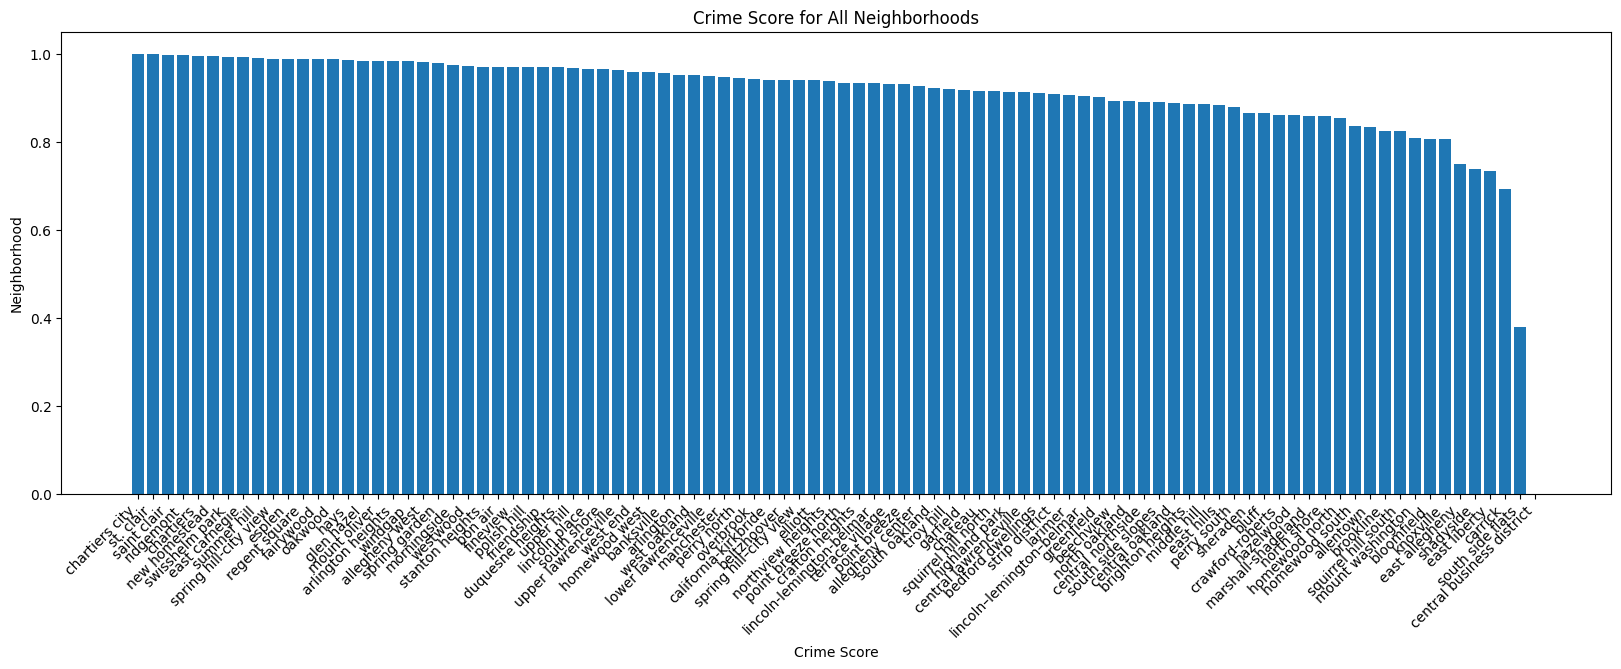

In [11]:
plt.figure(figsize=(20,6)) 
plt.bar(crime_counts_sorted['Neighborhood'], crime_counts_sorted['crime_score'])

plt.xlabel("Crime Score")
plt.ylabel("Neighborhood")
plt.title("Crime Score for All Neighborhoods")
plt.xticks( rotation=45,
    ha="right")

plt.show()

## Crime submetric Analysis

In this section,I analyzed crime data for different neighborhoods in Pittsburgh. I grouped the data by neighborhood and counted how many crime incidents happened in each area. Since fewer crimes mean a safer neighborhood, we converted the counts into a score.We normalized the values so they are between 0 and 1, and reversed them so that higher scores mean safer places.We also created visualizations to compare crime levels across neighborhoods. This result will be used later together with other data to evaluate overall livability.


## 2.analysis for the environment: tree-density in each neighborhood (by Marcos)

In [12]:
df = pd.read_csv(r"C:\CMPINF\Pittsburgh_Trees.csv")
#Remove dud entries
df = df[~df['common_name'].isin([
    'Non-sufficient space', 'Unknown', 'Unknown Shrub',
    'Vacant Site Large', 'Vacant Site Medium',
    'Vacant Site Not Suitable', 'Vacant Site Small'
])]

#print
df

C:\Users\袁子涵\AppData\Local\Temp\ipykernel_27796\1532847546.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\CMPINF\Pittsburgh_Trees.csv")


,_id,id,address_number,street,common_name,scientific_name,height,width,growth_space_length,growth_space_width,...,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
0,1,754166088,7428.0,MONTICELLO ST,Stump,Stump,0.0,0.0,10.0,2.0,...,Homewood North,9.0,13.0,4.200313e+10,2.0,13.0,5.0,3-17,40.458169,-79.889724
1,2,1946899269,220.0,BALVER AVE,Linden: Littleleaf,Tilia cordata,0.0,0.0,99.0,99.0,...,Oakwood,2.0,28.0,4.200356e+10,5.0,28.0,6.0,1-19,40.429269,-80.067868
2,3,1431517397,2822.0,SIDNEY ST,Maple: Red,Acer rubrum,22.0,6.0,6.0,3.0,...,South Side Flats,3.0,16.0,4.200316e+10,3.0,16.0,3.0,4-24,40.426797,-79.965035
3,4,994063598,608.0,SUISMON ST,Maple: Freeman,Acer x freemanii,25.0,10.0,3.0,3.0,...,East Allegheny,1.0,23.0,4.200356e+10,1.0,23.0,1.0,1-6,40.455503,-79.999276
4,5,1591838573,1135.0,N NEGLEY AVE,Maple: Norway,Acer platanoides,52.0,13.0,99.0,99.0,...,Highland Park,7.0,11.0,4.200311e+10,2.0,11.0,5.0,3-9,40.476667,-79.924106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45704,46384,39047675,499 N LANG AVE,N LANG AVE,Maple: Norway,Acer platanoides,15.0,15.0,NaN,NaN,...,Point Breeze North,9.0,14.0,4.200314e+10,2.0,14.0,4.0,3-14,40.453499,-79.901280
45705,46417,1827907131,NaN,NaN,Maple: Sugar,Acer saccharum,NaN,NaN,NaN,NaN,...,Squirrel Hill North,8.0,14.0,4.200314e+10,3.0,14.0,4.0,2-8,40.443065,-79.934139
45706,46418,1513723611,NaN,NaN,Maple: Sugar,Acer saccharum,NaN,NaN,NaN,NaN,...,Squirrel Hill North,8.0,14.0,4.200314e+10,3.0,14.0,4.0,2-8,40.443010,-79.934095
45707,46419,1830872418,NaN,NaN,Maple: Sugar,Acer saccharum,NaN,NaN,NaN,NaN,...,Squirrel Hill North,8.0,14.0,4.200314e+10,3.0,14.0,4.0,2-8,40.442946,-79.934062


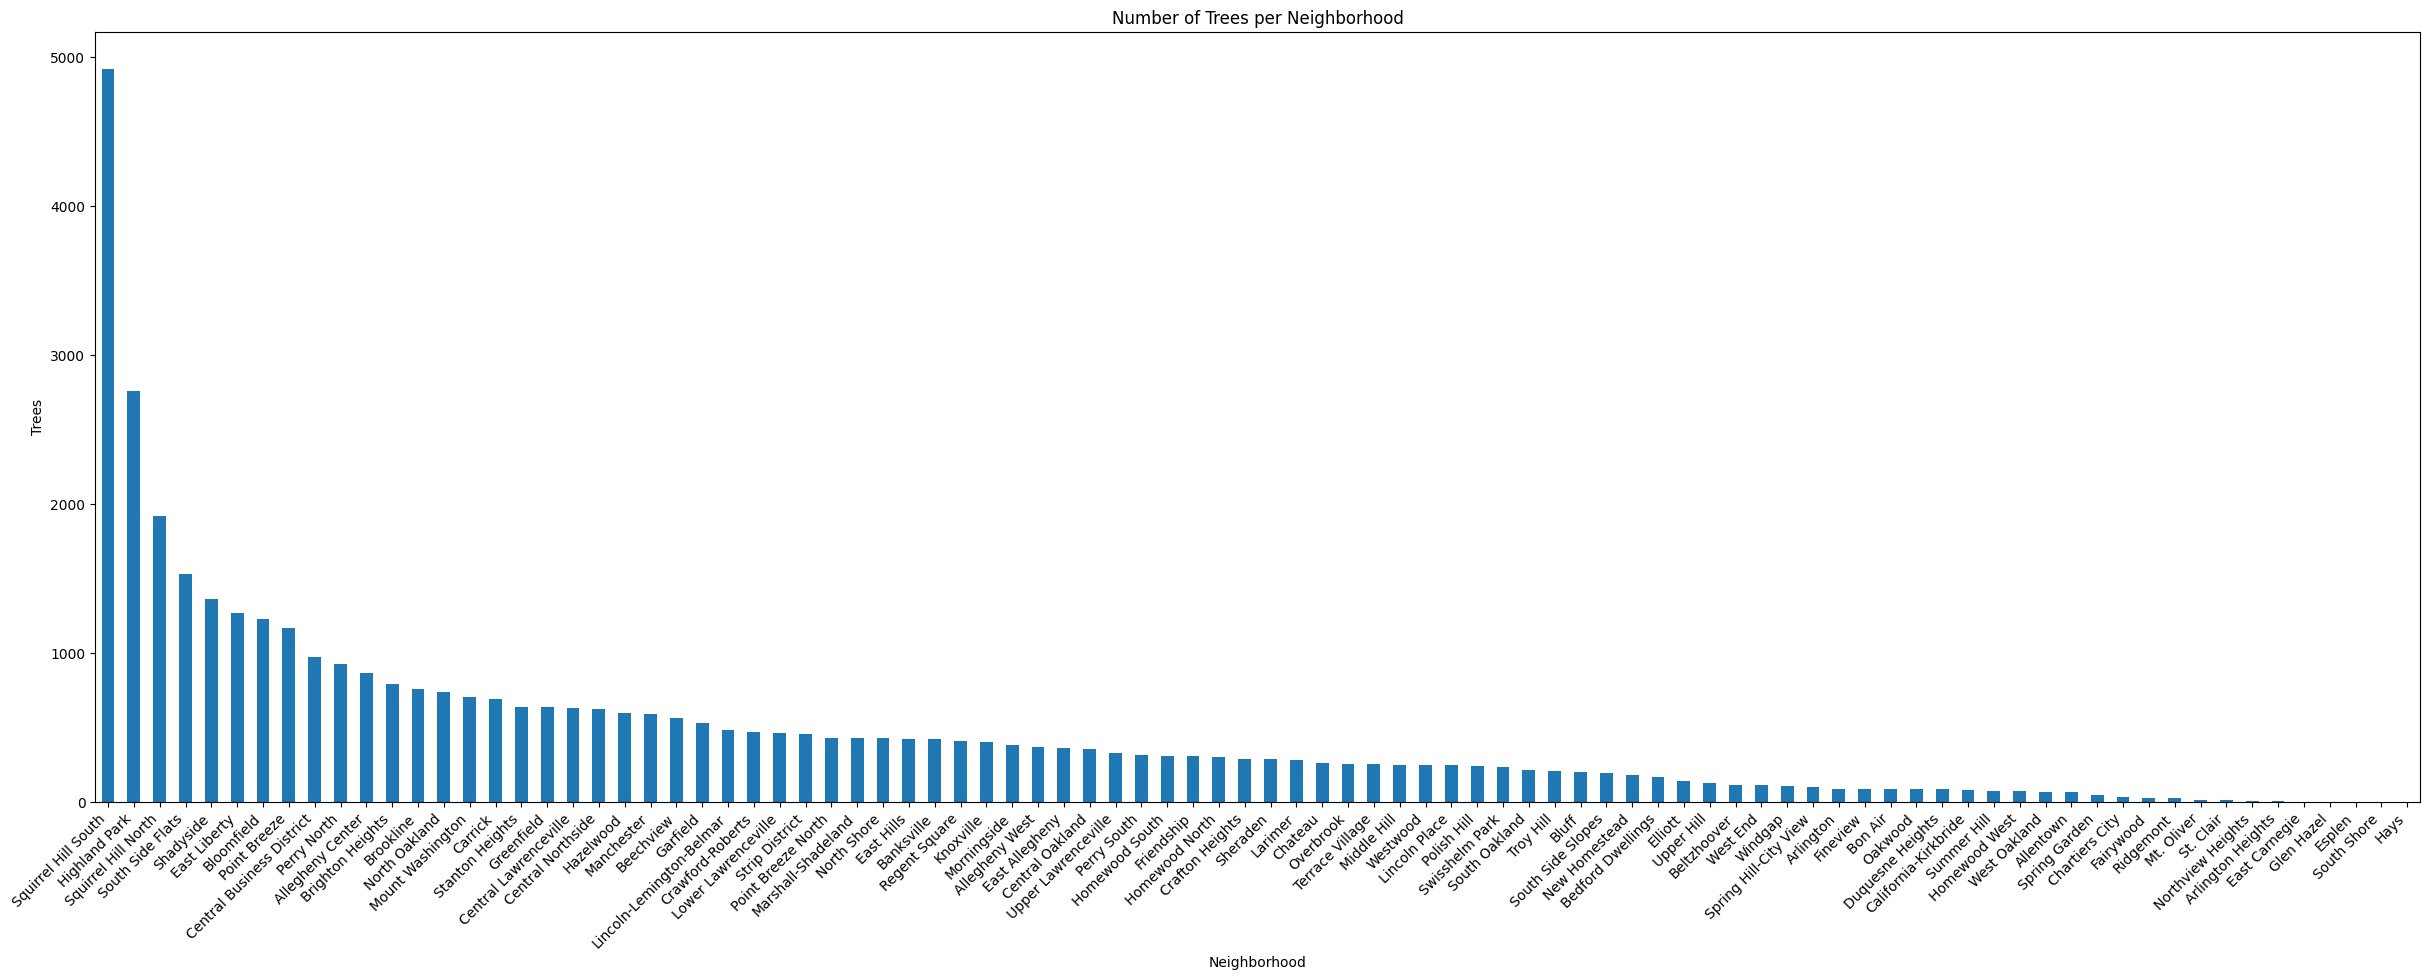

In [13]:
#Plot trees by neighborhood
plt.figure(figsize=(30, 10))
df['neighborhood'].value_counts().plot.bar()
plt.title('Number of Trees per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Trees')
plt.xticks(
    rotation=45,
    ha="right"
)
plt.show()

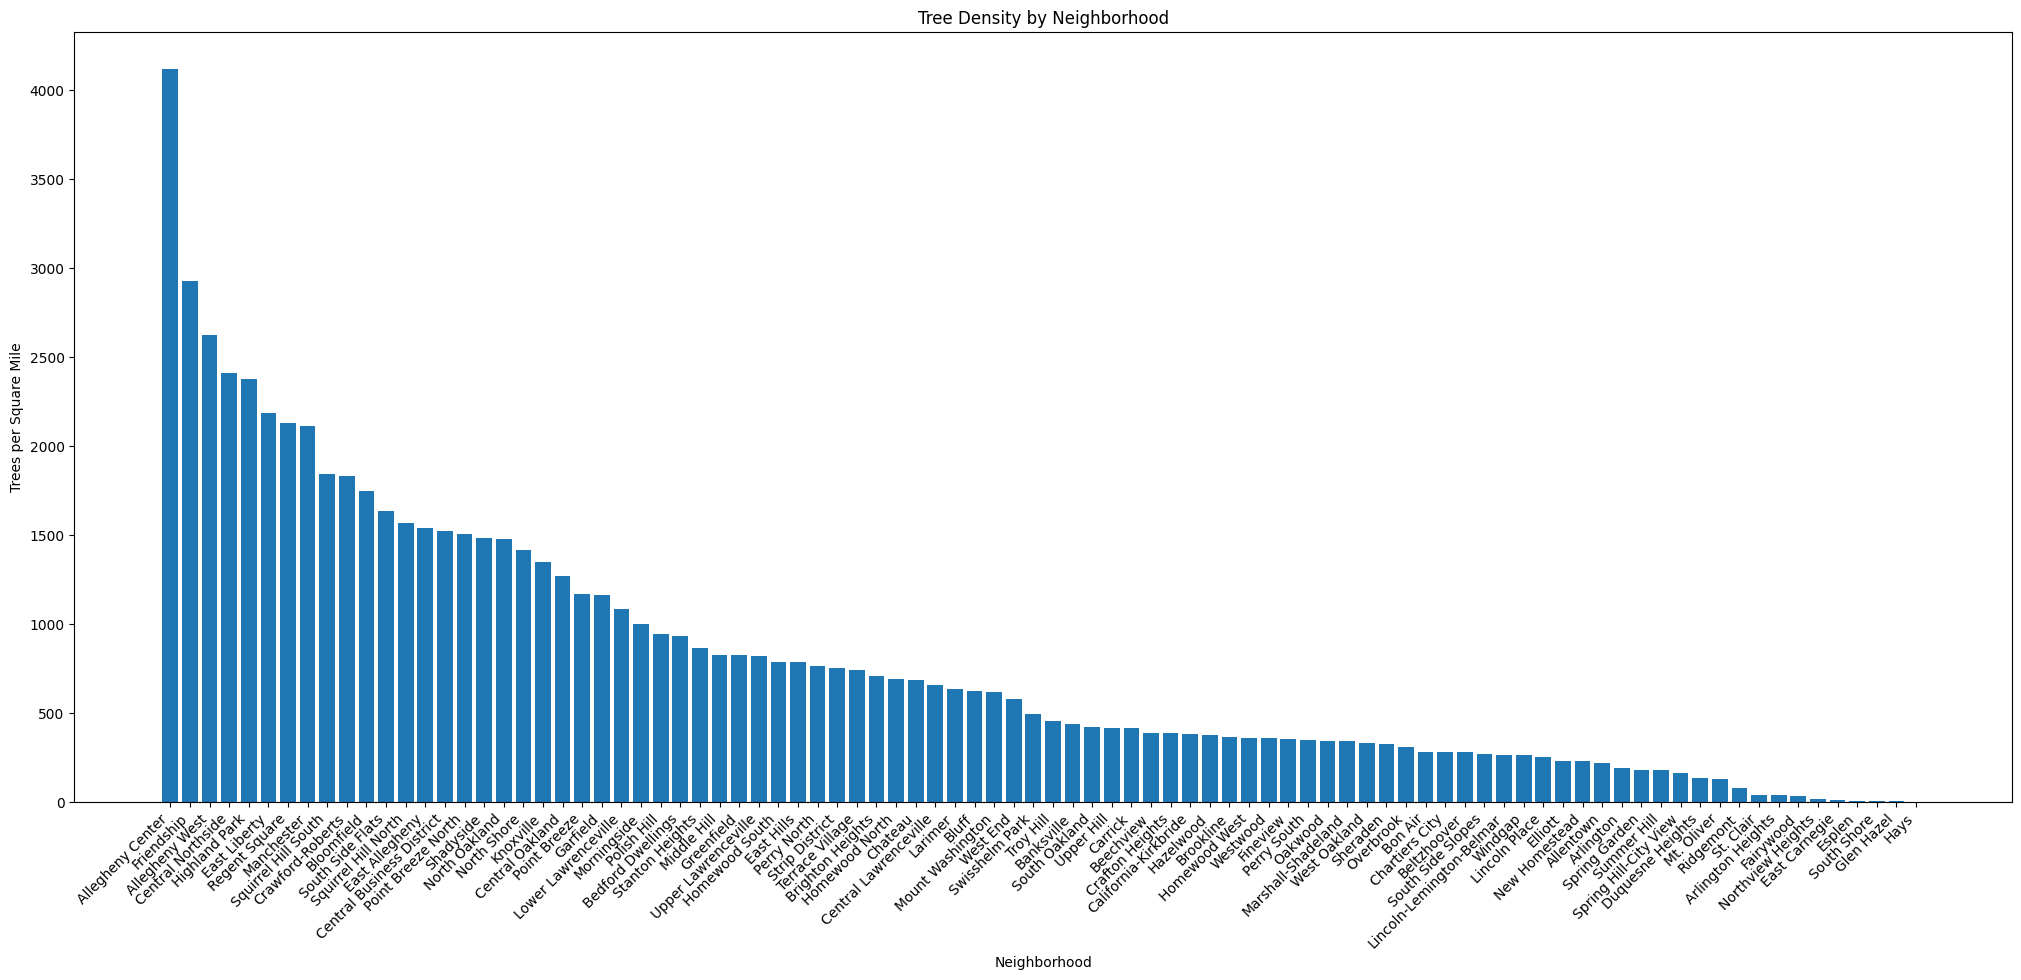

In [14]:
#Chart tree to size ratio
#Neighborhood size taken from https://web.archive.org/web/20070810193148/http://www.city.pittsburgh.pa.us/cp/assets/census/2000_census_pgh_jan06.pdf
neighborhood_df = pd.read_csv(r"C:\CMPINF\neighborhood_size.csv")
#Calculate the ratio of trees/square mile
tree_counts = df['neighborhood'].value_counts()
neighborhood_df['trees'] = neighborhood_df['neighborhood'].map(tree_counts).fillna(0).astype(int)
neighborhood_df['tree_density'] = neighborhood_df['trees'] / neighborhood_df['neighborhood_size'].replace(0, pd.NA)
#Plot
#sort
plot_df = neighborhood_df.sort_values('tree_density', ascending=False)
plt.figure(figsize=(25, 10))
plt.bar(plot_df['neighborhood'], plot_df['tree_density'])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Trees per Square Mile")
plt.title("Tree Density by Neighborhood")
plt.xticks(
    rotation=45,
    ha="right"
)
plt.show()

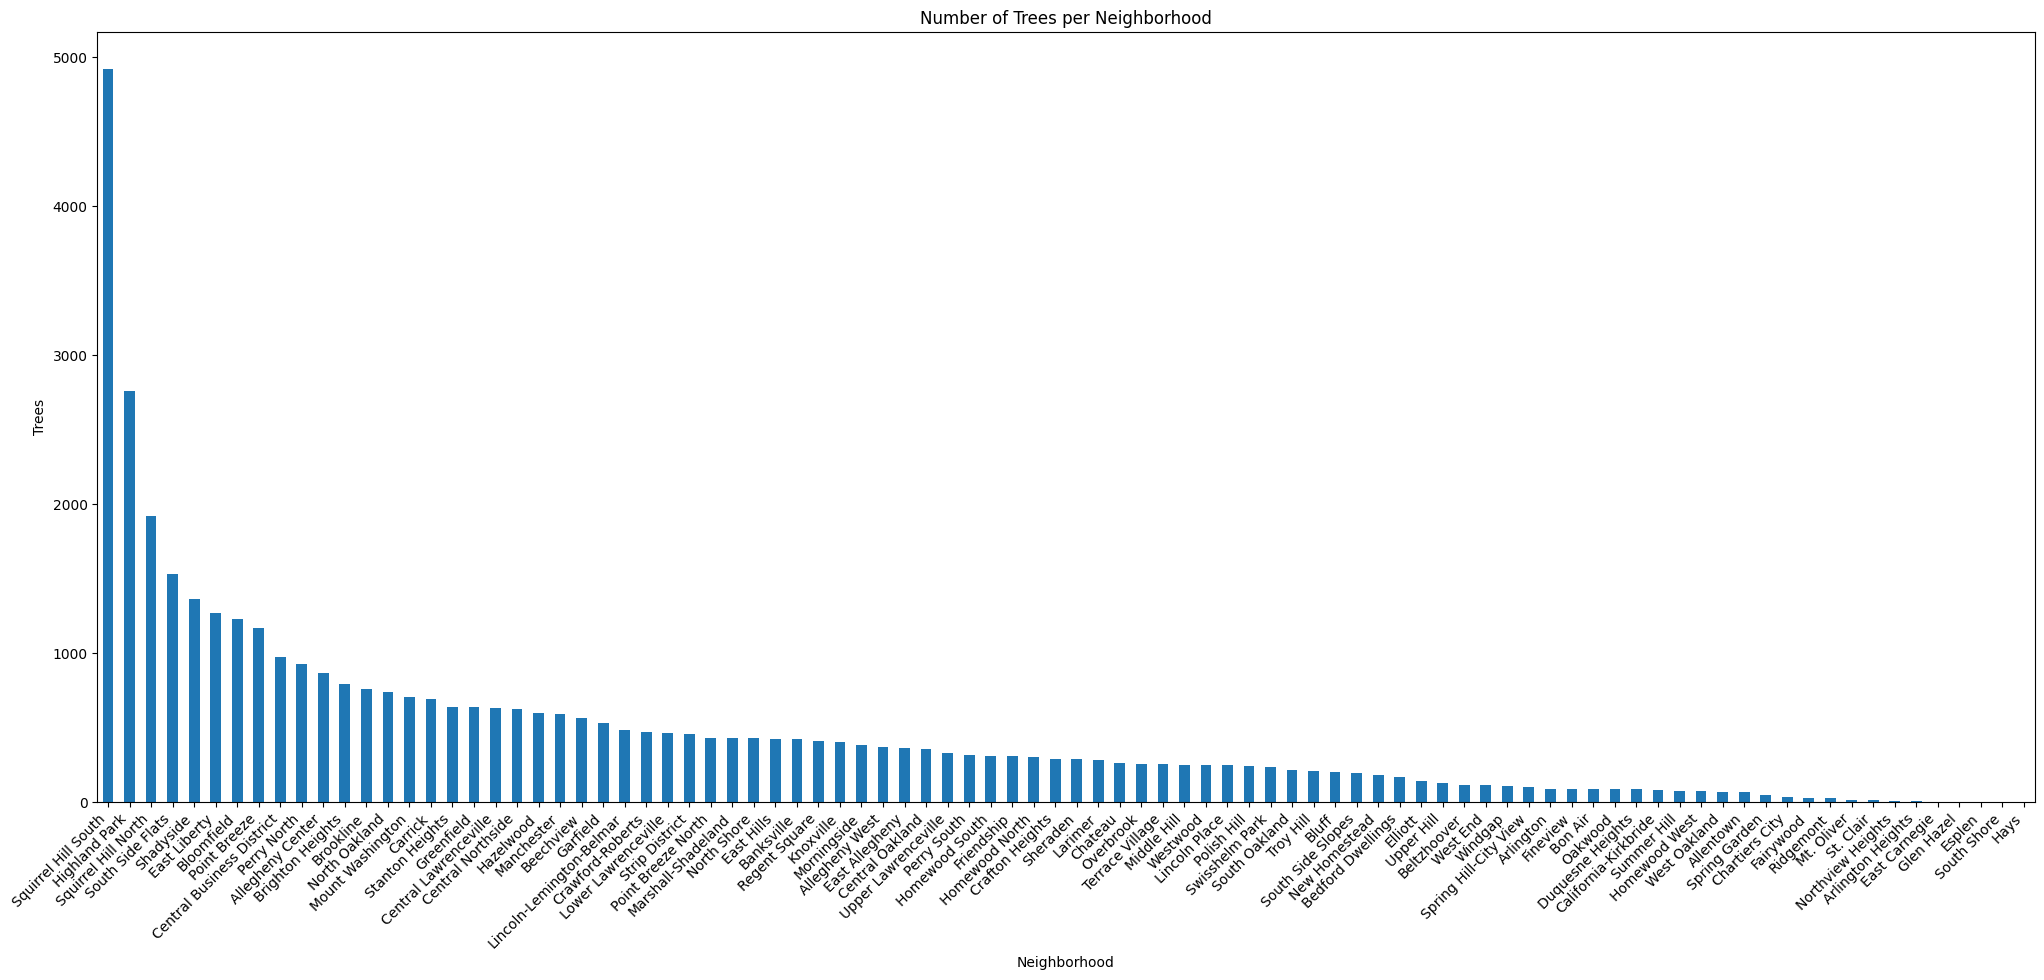

In [15]:
#Plot trees by neighborhood
plt.figure(figsize=(25, 10))
df['neighborhood'].value_counts().plot.bar()
plt.title('Number of Trees per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Trees')
plt.xticks(
    rotation=45,
    ha="right"
)
plt.show()

In [16]:
# normalize density → 0-1
plot_df['tree_score'] = (
    plot_df['tree_density'] - plot_df['tree_density'].min()
) / (
    plot_df['tree_density'].max() - plot_df['tree_density'].min()
)

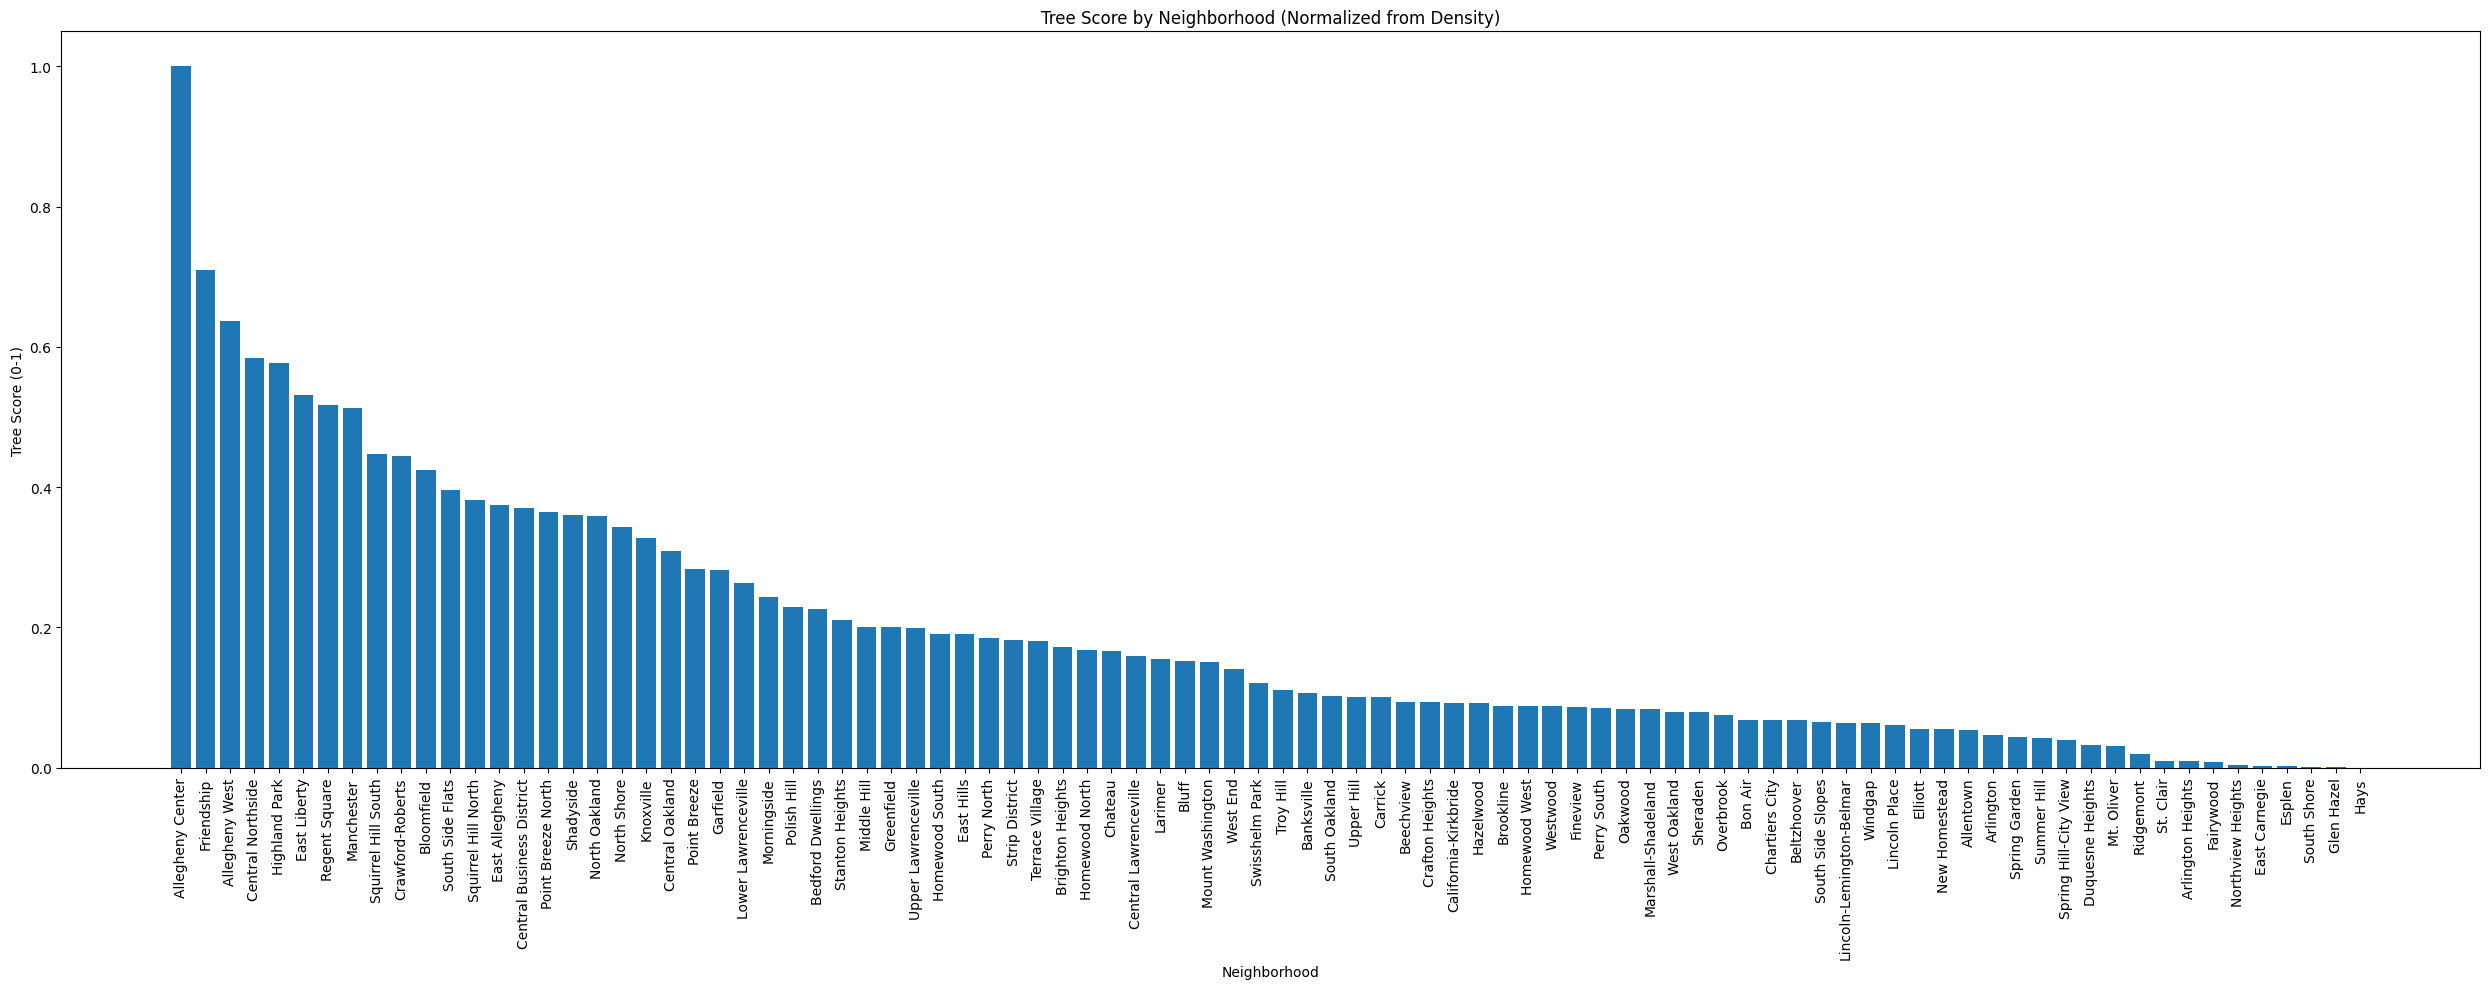

In [17]:
plot_df = plot_df.sort_values('tree_score', ascending=False)

plt.figure(figsize=(25, 10))

plt.bar(plot_df['neighborhood'], plot_df['tree_score'])

plt.xlabel("Neighborhood")
plt.ylabel("Tree Score (0-1)")
plt.title("Tree Score by Neighborhood (Normalized from Density)")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Tree subMetric Analysis

For the tree metric, we first look at how many trees are in each neighborhood. However, we realized that just using the total number of trees is not very significant, because larger neighborhoods will naturally have more trees. To fix this, we calculated tree density (trees per square mile) by combining the tree data with neighborhood size data.Using density makes the comparison more meaningful, since it shows how “green” a neighborhood actually is relative to its size. After that, we normalized the density values to a 0–1 range to create a tree score. This step is important because it allows us to compare and combine this metric with others.From the results, we can see that some neighborhoods have much higher tree density than others, meaning they likely have more green space and a better environment. Overall, using tree density instead of raw counts gives a more accurate representation of livability.

## 3. analysis for the convenience: convenience score in each neighborhood (by Yuzhe)

### 1. Load the datasets

- `neighborhoods.geojson`: Pittsburgh neighborhood boundaries.
- `stops.geojson`: Pittsburgh Regional Transit stop locations.
- `neighborhood_size.csv`: neighborhood area/size table used to normalize the metric.
- `Pittsburgh_Trees.csv`: optional, used only to demonstrate alignment with another project part

In [18]:
pip install geopandas shapely pyproj fiona matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [19]:
# If needed, install geopandas before running this notebook:
# %pip install geopandas shapely pyproj fiona matplotlib pandas

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Put this notebook in the same folder as the data files.
# In ChatGPT's sandbox, the uploaded files are usually in /mnt/data.
DATA_DIR = Path("C:\CMPINF")
if not (DATA_DIR / "neighborhoods.geojson").exists() and Path("/mnt/data/neighborhoods.geojson").exists():
    DATA_DIR = Path("/mnt/data")

NEIGHBORHOODS_FILE = DATA_DIR / "neighborhoods.geojson"
STOPS_FILE = DATA_DIR / "stops.geojson"
SIZE_FILE = DATA_DIR / "neighborhood_size.csv"
TREES_FILE = DATA_DIR / "Pittsburgh_Trees.csv"

for path in [NEIGHBORHOODS_FILE, STOPS_FILE, SIZE_FILE]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

print("Required data files found.")

Required data files found.


In [20]:
neighborhoods = gpd.read_file(NEIGHBORHOODS_FILE)
stops = gpd.read_file(STOPS_FILE)
size = pd.read_csv(SIZE_FILE)

print("Neighborhood boundaries:", neighborhoods.shape)
print("Transit stops:", stops.shape)
print("Neighborhood size:", size.shape)

display(neighborhoods.head(3))
display(stops.head(3))
display(size.head())

Neighborhood boundaries: (90, 40)
Transit stops: (6426, 36)
Neighborhood size: (90, 2)


,OBJECTID,fid_blockg,statefp10,countyfp10,tractce10,blkgrpce10,geoid10,namelsad10,mtfcc10,funcstat10,aland10,awater10,intptlat10,intptlon10,shape_leng,fid_neighb,perimeter,neighbor_,neighbor_i,hood,hood_no,acres,sqmiles,dpwdiv,unique_id,sectors,shape_le_1,shape_ar_1,page_number,plannerassign,created_user,created_date,last_edited_user,last_edited_date,temp,pghdb_sde_Neighborhood_2010_are,GlobalID,Shape__Area,Shape__Length,geometry
0,1,233,42,003,140500,3,420031405003,Block Group 3,G5030,S,172851,0,+40.4523867,-079.9073195,6787.527650,71,136797.979285,48,2130,Point Breeze North,64,193.229239,0.301921,2,113,11,13891.873348,7.968760e+06,15,Adriana Bowman,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 13:02:13+00:00,None,7968760.0,a642a6b6-a2a9-48d5-acf2-3e2ce87d4bc0,8.417067e+06,14181.728584,"POLYGON ((-79.90531 40.45549, -79.90488 40.455..."
1,2,203,42,003,140100,3,420031401003,Block Group 3,G5030,S,291302,0,+40.4427301,-079.9435821,8071.734942,66,136797.979285,55,2137,Squirrel Hill North,76,782.981547,1.223409,3,57,10,30343.651076,3.407871e+07,15,Christian Umbach,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 13:02:41+00:00,None,34078712.0,20d4605b-258e-441a-a57e-a28fdabb6d30,3.410837e+07,30326.819418,"POLYGON ((-79.92063 40.44423, -79.92052 40.443..."
2,3,86,42,003,101700,2,420031017002,Block Group 2,G5030,S,217979,0,+40.4672423,-079.9433700,6586.683658,39,136797.979285,18,2100,Garfield,35,292.726125,0.457385,2,113,12,14574.326687,1.275116e+07,15,"Vacant, contact Ose Akinlotan (Planning Manager)",SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 12:59:55+00:00,None,12751163.0,bf4065e7-c29c-48bd-b529-e7fd99077238,1.275115e+07,14577.426328,"POLYGON ((-79.93546 40.47257, -79.9353 40.4725..."


,OBJECTID,stop_id,stop_code,stop_name,stop_lat,stop_lon,stop_route,route_code,route_filter,route_sort,mode,direction,trips_wd,trips_sa,trips_su,trips_7d,svc_days,agency,feed_version,start_date,end_date,from_gtfs,change_log,comments,status_code,status_notes,status_start_date,status_end_date,GEOIDFQ,county,muni,hood,munihood_full,munihood_display,empty_feat,geometry
0,304230,E00175,2593,26TH ST AT PENN AVE FS (SPRING WAY),40.454586,-79.978073,E00175,"54,88,91",All Routes,00,BUS,IB,132,76,71,807,"WD,SA,SU",PRT,2602,"Sun, 26 Apr 2026 06:00:00 GMT","Thu, 31 Dec 2099 07:00:00 GMT",1,,,1,None,"Thu, 01 Jan 1970 06:00:00 GMT","Thu, 31 Dec 2099 06:00:00 GMT",1000000US420030203001073,"Allegheny County, PA","Pittsburgh city (Allegheny, PA)",Strip District,"Strip District, Pittsburgh",Strip District,0,POINT (-79.97807 40.45459)
1,304234,E00180,2161,28TH ST AT LIBERTY AVE,40.456319,-79.974662,E00180,54,All Routes,00,BUS,IB,26,17,12,159,"WD,SA,SU",PRT,2602,"Sun, 26 Apr 2026 06:00:00 GMT","Thu, 31 Dec 2099 07:00:00 GMT",1,,,1,None,"Thu, 01 Jan 1970 06:00:00 GMT","Thu, 31 Dec 2099 06:00:00 GMT",1000000US420030605001001,"Allegheny County, PA","Pittsburgh city (Allegheny, PA)",Polish Hill,"Polish Hill, Pittsburgh",Polish Hill,0,POINT (-79.97466 40.45632)
2,304236,E00270,2410,32ND ST AT SPRING WAY,40.460445,-79.969566,E00270,"54,88,91",All Routes,00,BUS,OB,132,78,72,810,"WD,SA,SU",PRT,2602,"Sun, 26 Apr 2026 06:00:00 GMT","Thu, 31 Dec 2099 07:00:00 GMT",1,,,1,None,"Thu, 01 Jan 1970 06:00:00 GMT","Thu, 31 Dec 2099 06:00:00 GMT",1000000US420030203001007,"Allegheny County, PA","Pittsburgh city (Allegheny, PA)",Strip District,"Strip District, Pittsburgh",Strip District,0,POINT (-79.96957 40.46044)


,neighborhood,neighborhood_size
0,Allegheny Center,0.210
1,Allegheny West,0.141
2,Allentown,0.295
3,Arlington,0.470
4,Arlington Heights,0.132


### 2. Clean and align neighborhood names

Different datasets sometimes store the same neighborhood name in slightly different columns.  
Here, we make one shared column called `neighborhood` so all parts of the project can merge correctly.

In [21]:
def clean_name(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().replace("\u2019", "'").replace("\u2018", "'").replace("\u2013", "-").replace("\u2014", "-")

# The boundary file uses 'hood' for neighborhood name.
neighborhoods["neighborhood"] = neighborhoods["hood"].apply(clean_name)
stops["stop_hood_original"] = stops.get("hood", pd.Series([np.nan] * len(stops))).apply(clean_name)
size["neighborhood"] = size["neighborhood"].apply(clean_name)

# Keep one row per neighborhood boundary. Some boundary datasets can contain repeated block-group pieces.
# Dissolve makes sure each neighborhood has one combined shape.
neighborhoods_aligned = neighborhoods[["neighborhood", "geometry"]].dissolve(by="neighborhood", as_index=False)

print("Unique neighborhoods in boundary file:", neighborhoods_aligned["neighborhood"].nunique())
print("Unique neighborhoods in size file:", size["neighborhood"].nunique())

# Check whether the size file and boundary file align.
boundary_names = set(neighborhoods_aligned["neighborhood"])
size_names = set(size["neighborhood"])

print("\nIn size file but not boundary file:")
print(sorted(size_names - boundary_names))

print("\nIn boundary file but not size file:")
print(sorted(boundary_names - size_names))

Unique neighborhoods in boundary file: 90
Unique neighborhoods in size file: 90

In size file but not boundary file:
[]

In boundary file but not size file:
[]


### 3. Spatially assign stops to neighborhoods

Even though the transit-stop file already has a `hood` column, a spatial join is safer because it uses the actual stop point and neighborhood boundary.  
This helps keep the neighborhood alignment consistent with the boundary dataset.

In [22]:
# Use a projected CRS for Pittsburgh/PA area so spatial operations are reliable.
# EPSG:2272 is Pennsylvania South ft; EPSG:4326 is lat/lon.
neighborhoods_proj = neighborhoods_aligned.to_crs(epsg=2272)
stops_proj = stops.to_crs(epsg=2272)

# Keep only useful stop columns.
stop_cols = ["stop_id", "stop_name", "mode", "route_code", "trips_7d", "geometry"]
stop_cols = [c for c in stop_cols if c in stops_proj.columns]
stops_small = stops_proj[stop_cols].copy()

# Spatial join: assign each stop point to the neighborhood polygon containing it.
stops_with_neighborhood = gpd.sjoin(
    stops_small,
    neighborhoods_proj[["neighborhood", "geometry"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"])

print("Stops assigned to neighborhoods:", stops_with_neighborhood["neighborhood"].notna().sum())
print("Stops not inside a Pittsburgh neighborhood boundary:", stops_with_neighborhood["neighborhood"].isna().sum())

display(stops_with_neighborhood.head())

Stops assigned to neighborhoods: 2678
Stops not inside a Pittsburgh neighborhood boundary: 3748


,stop_id,stop_name,mode,route_code,trips_7d,geometry,neighborhood
0,E00175,26TH ST AT PENN AVE FS (SPRING WAY),BUS,"54,88,91",807,POINT (1348526.294 416279.674),Strip District
1,E00180,28TH ST AT LIBERTY AVE,BUS,54,159,POINT (1349491.125 416886.878),Polish Hill
2,E00270,32ND ST AT SPRING WAY,BUS,"54,88,91",810,POINT (1350946.554 418353.827),Strip District
3,E00420,40TH ST AT BUTLER ST,BUS,93,171,POINT (1353095.904 421251.287),Lower Lawrenceville
4,E00430,40TH ST AT DAVIDSON ST FS,BUS,93,171,POINT (1353434.569 420949.45),Central Lawrenceville


### 4. Build the convenience metric

I use three related measures:

1. **Stop Count**: number of transit stops in each neighborhood.  
2. **Stops per Square Mile**: stop count adjusted by neighborhood size, so large neighborhoods do not automatically win.  
3. **Trips per Square Mile**: total weekly trips adjusted by neighborhood size, so a neighborhood with more frequent service scores higher.

The final convenience score is a normalized combination:

`convenience_score = 0.5 * normalized(stops_per_sq_mile) + 0.5 * normalized(trips_per_sq_mile)`

In [23]:
# Count stops and sum weekly trips by neighborhood.
stop_summary = (
    stops_with_neighborhood
    .dropna(subset=["neighborhood"])
    .groupby("neighborhood")
    .agg(
        stop_count=("stop_id", "count"),
        weekly_trips=("trips_7d", "sum")
    )
    .reset_index()
)

# Merge with neighborhood size.
convenience = (
    neighborhoods_aligned[["neighborhood"]]
    .merge(size, on="neighborhood", how="left")
    .merge(stop_summary, on="neighborhood", how="left")
)

convenience["stop_count"] = convenience["stop_count"].fillna(0).astype(int)
convenience["weekly_trips"] = convenience["weekly_trips"].fillna(0)

# If neighborhood_size is square miles, use it directly.
# If your class defined it differently, rename the output label but keep the same normalization idea.
convenience["stops_per_sq_mile"] = convenience["stop_count"] / convenience["neighborhood_size"]
convenience["trips_per_sq_mile"] = convenience["weekly_trips"] / convenience["neighborhood_size"]

def minmax(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

convenience["stop_density_norm"] = minmax(convenience["stops_per_sq_mile"])
convenience["trip_density_norm"] = minmax(convenience["trips_per_sq_mile"])

convenience["convenience_score"] = (
    0.5 * convenience["stop_density_norm"] +
    0.5 * convenience["trip_density_norm"]
)

convenience_ranked = convenience.sort_values("convenience_score", ascending=False).reset_index(drop=True)
convenience_ranked["rank"] = convenience_ranked.index + 1

display(convenience_ranked)

,neighborhood,neighborhood_size,stop_count,weekly_trips,stops_per_sq_mile,trips_per_sq_mile,stop_density_norm,trip_density_norm,convenience_score,rank
0,West Oakland,0.215,32,40303,148.837209,187455.813953,0.934948,1.000000,0.967474,1
1,Crawford-Roberts,0.258,41,25063,158.914729,97143.410853,1.000000,0.517335,0.758668,2
2,Central Business District,0.640,69,88486,107.812500,138259.375000,0.670127,0.737075,0.703601,3
3,Allegheny Center,0.210,27,21976,128.571429,104647.619048,0.804129,0.557441,0.680785,4
4,Friendship,0.106,15,8547,141.509434,80632.075472,0.887646,0.429092,0.658369,5
5,Bloomfield,0.702,92,37354,131.054131,53210.826211,0.820155,0.282542,0.551349,6
6,North Oakland,0.499,42,50305,84.168337,100811.623246,0.517500,0.536940,0.527220,7
7,East Liberty,0.581,63,39795,108.433735,68493.975904,0.674137,0.364221,0.519179,8
8,East Allegheny,0.236,28,12392,118.644068,52508.474576,0.740046,0.278789,0.509417,9
9,Larimer,0.445,52,20609,116.853933,46312.359551,0.728491,0.245674,0.487082,10


### 5.  neighborhoods by transit convenience scores

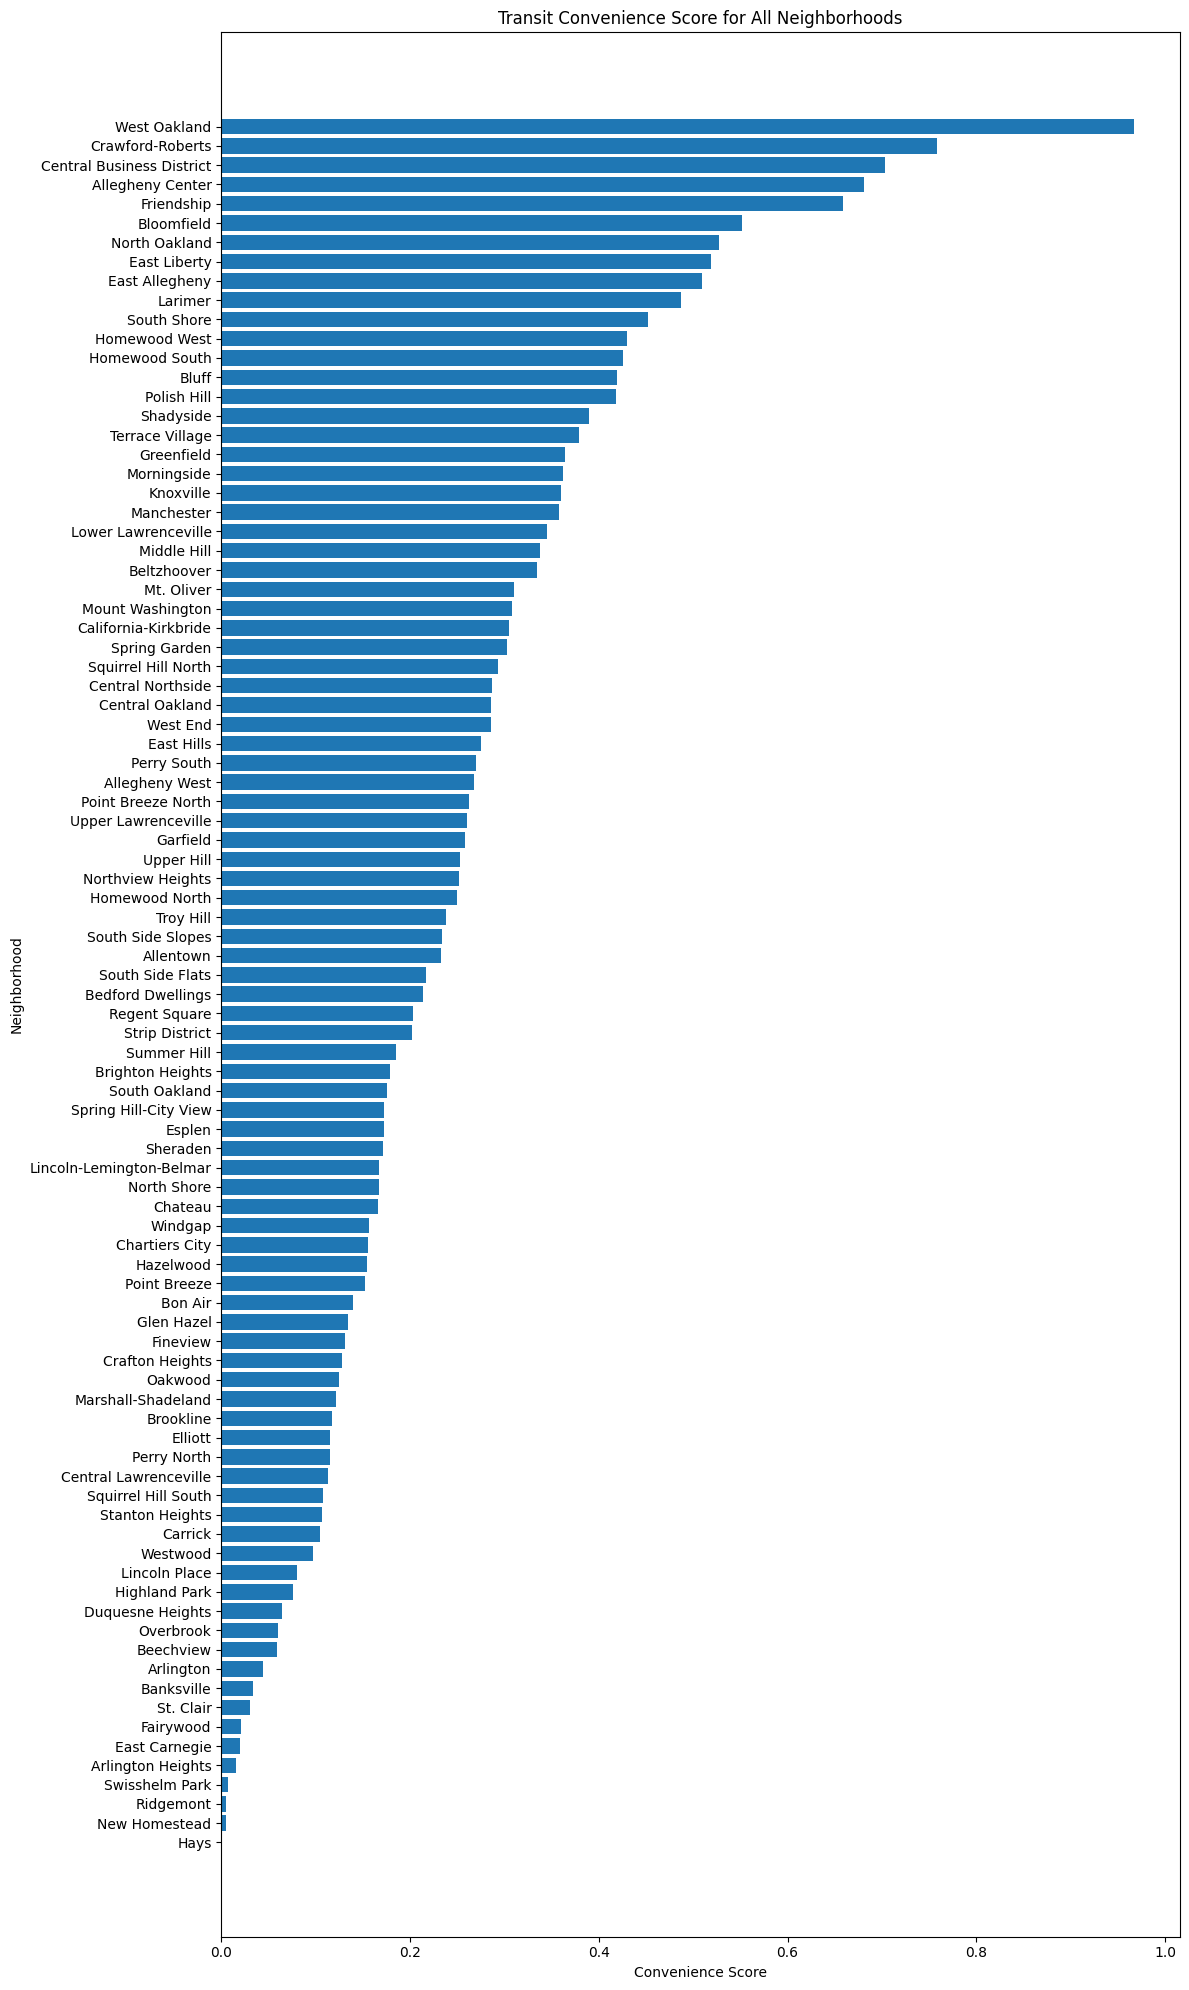

In [24]:
all_data = convenience_ranked.sort_values("convenience_score", ascending=True)

plt.figure(figsize=(12, 20)) 

plt.barh(all_data["neighborhood"], all_data["convenience_score"])

plt.xlabel("Convenience Score")
plt.ylabel("Neighborhood")
plt.title("Transit Convenience Score for All Neighborhoods")

plt.tight_layout()
plt.show()

### 6. Map the convenience score

This map helps show whether the most convenient neighborhoods are clustered around central Pittsburgh or spread across the city.

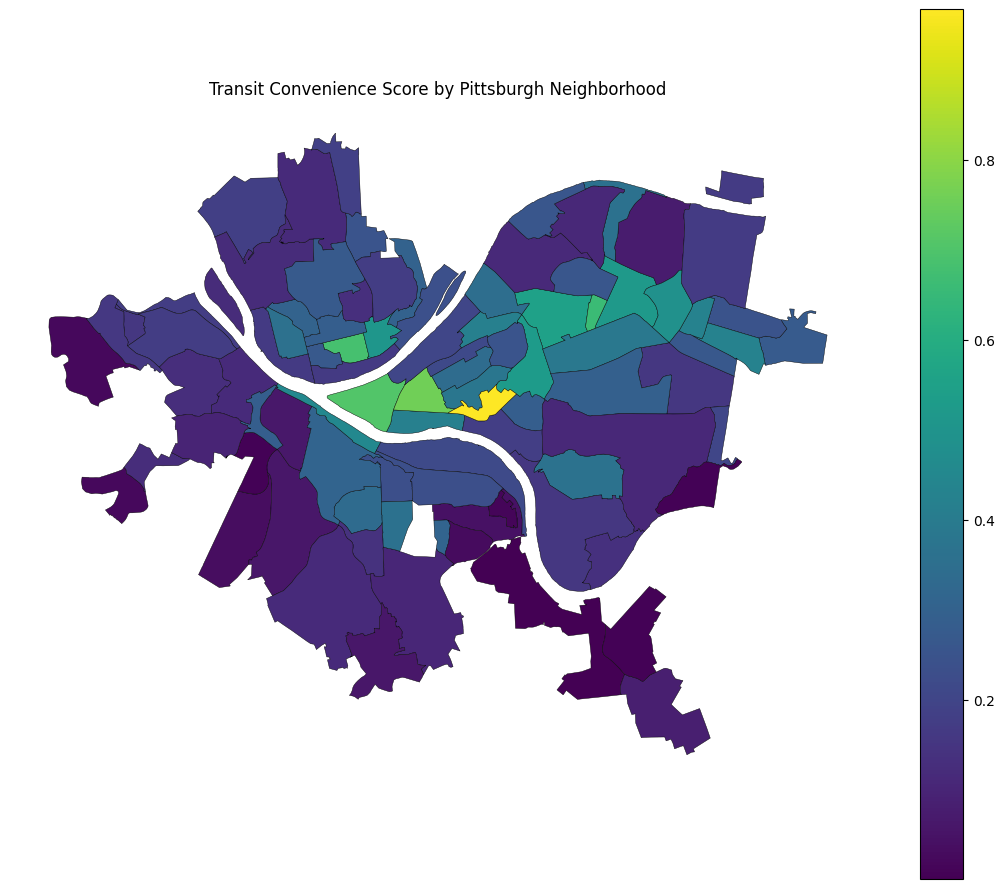

In [25]:
map_gdf = neighborhoods_aligned.merge(
    convenience_ranked[["neighborhood", "convenience_score", "rank", "stop_count", "weekly_trips", "stops_per_sq_mile", "trips_per_sq_mile"]],
    on="neighborhood",
    how="left"
)

fig, ax = plt.subplots(figsize=(11, 9))
map_gdf.plot(
    column="convenience_score",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)
ax.set_title("Transit Convenience Score by Pittsburgh Neighborhood")
ax.axis("off")
plt.tight_layout()
plt.show()

In [26]:
aligned_project_table = convenience_ranked.copy()

if TREES_FILE.exists():
    trees = pd.read_csv(TREES_FILE, usecols=["neighborhood"])
    trees["neighborhood"] = trees["neighborhood"].apply(clean_name)

    tree_summary = (
        trees
        .dropna(subset=["neighborhood"])
        .groupby("neighborhood")
        .size()
        .reset_index(name="tree_count")
    )

    aligned_project_table = aligned_project_table.merge(tree_summary, on="neighborhood", how="left")
    aligned_project_table["tree_count"] = aligned_project_table["tree_count"].fillna(0).astype(int)

    print("Tree data found and aligned.")
else:
    print("Tree file not found. Skipping tree alignment.")

display(aligned_project_table)

Tree data found and aligned.


,neighborhood,neighborhood_size,stop_count,weekly_trips,stops_per_sq_mile,trips_per_sq_mile,stop_density_norm,trip_density_norm,convenience_score,rank,tree_count
0,West Oakland,0.215,32,40303,148.837209,187455.813953,0.934948,1.000000,0.967474,1,78
1,Crawford-Roberts,0.258,41,25063,158.914729,97143.410853,1.000000,0.517335,0.758668,2,568
2,Central Business District,0.640,69,88486,107.812500,138259.375000,0.670127,0.737075,0.703601,3,1002
3,Allegheny Center,0.210,27,21976,128.571429,104647.619048,0.804129,0.557441,0.680785,4,867
4,Friendship,0.106,15,8547,141.509434,80632.075472,0.887646,0.429092,0.658369,5,362
5,Bloomfield,0.702,92,37354,131.054131,53210.826211,0.820155,0.282542,0.551349,6,1436
6,North Oakland,0.499,42,50305,84.168337,100811.623246,0.517500,0.536940,0.527220,7,775
7,East Liberty,0.581,63,39795,108.433735,68493.975904,0.674137,0.364221,0.519179,8,1366
8,East Allegheny,0.236,28,12392,118.644068,52508.474576,0.740046,0.278789,0.509417,9,391
9,Larimer,0.445,52,20609,116.853933,46312.359551,0.728491,0.245674,0.487082,10,306


### Tree Metric Analysis

To measure neighborhood convenience, I used public transit access as the main metric. I counted the number of Pittsburgh Regional Transit stops inside each Pittsburgh neighborhood boundary and also considered the total weekly trips served by those stops. Because neighborhoods have different sizes, I normalized the results by neighborhood area, using stops per square mile and trips per square mile. This makes the comparison fairer because a large neighborhood does not automatically score higher only because it covers more land. The final convenience score combines normalized stop density and normalized trip density. Based on this metric, **[top neighborhood after running notebook]** ranks highest because it has strong transit access relative to its size and frequent service compared with other neighborhoods. This suggests that residents in this neighborhood likely have easier access to transportation for daily needs such as school, work, shopping, and services.


# part 3  Final Metric for Livability

## 1. final metric form description



After computing the three sub-metrics (crime, tree density, and transit convenience), we normalized each of them to a 0–1 scale. This allows all metrics to be directly comparable despite having different units and ranges.
To determine the overall livability of each neighborhood, we combined the three scores using a weighted sum:

f(x, y, z) = 0.4x + 0.3y + 0.3z

where x represents the crime score, y represents the tree score, and z represents the convenience score.
We assigned a higher weight to crime (40%) because safety is a critical factor in determining livability. The remaining weights were evenly distributed between tree density and convenience (30% each), as both contribute to environmental quality and accessibility.
This approach provides a balanced and interpretable way to rank neighborhoods based on multiple factors.


## 2. algrithmn implementation

In [27]:
# crime
crime_df = crime_counts[['Neighborhood', 'crime_score']].rename(
    columns={'Neighborhood': 'neighborhood'}
)

# tree
tree_df = plot_df[['neighborhood', 'tree_score']]

# convenience
convenience_df = convenience_ranked[['neighborhood', 'convenience_score']]

In [28]:
for df_ in [crime_df, tree_df, convenience_df]:
    df_.loc[:, 'neighborhood'] = df_['neighborhood'].str.strip().str.lower()

In [29]:
final_df = crime_df.merge(tree_df, on='neighborhood') \
                   .merge(convenience_df, on='neighborhood')

In [30]:
final_df['final_score'] = (
    0.4 * final_df['crime_score'] +
    0.3 * final_df['tree_score'] +
    0.3 * final_df['convenience_score']
)

In [31]:
final_ranked = final_df.sort_values(by='final_score', ascending=False)

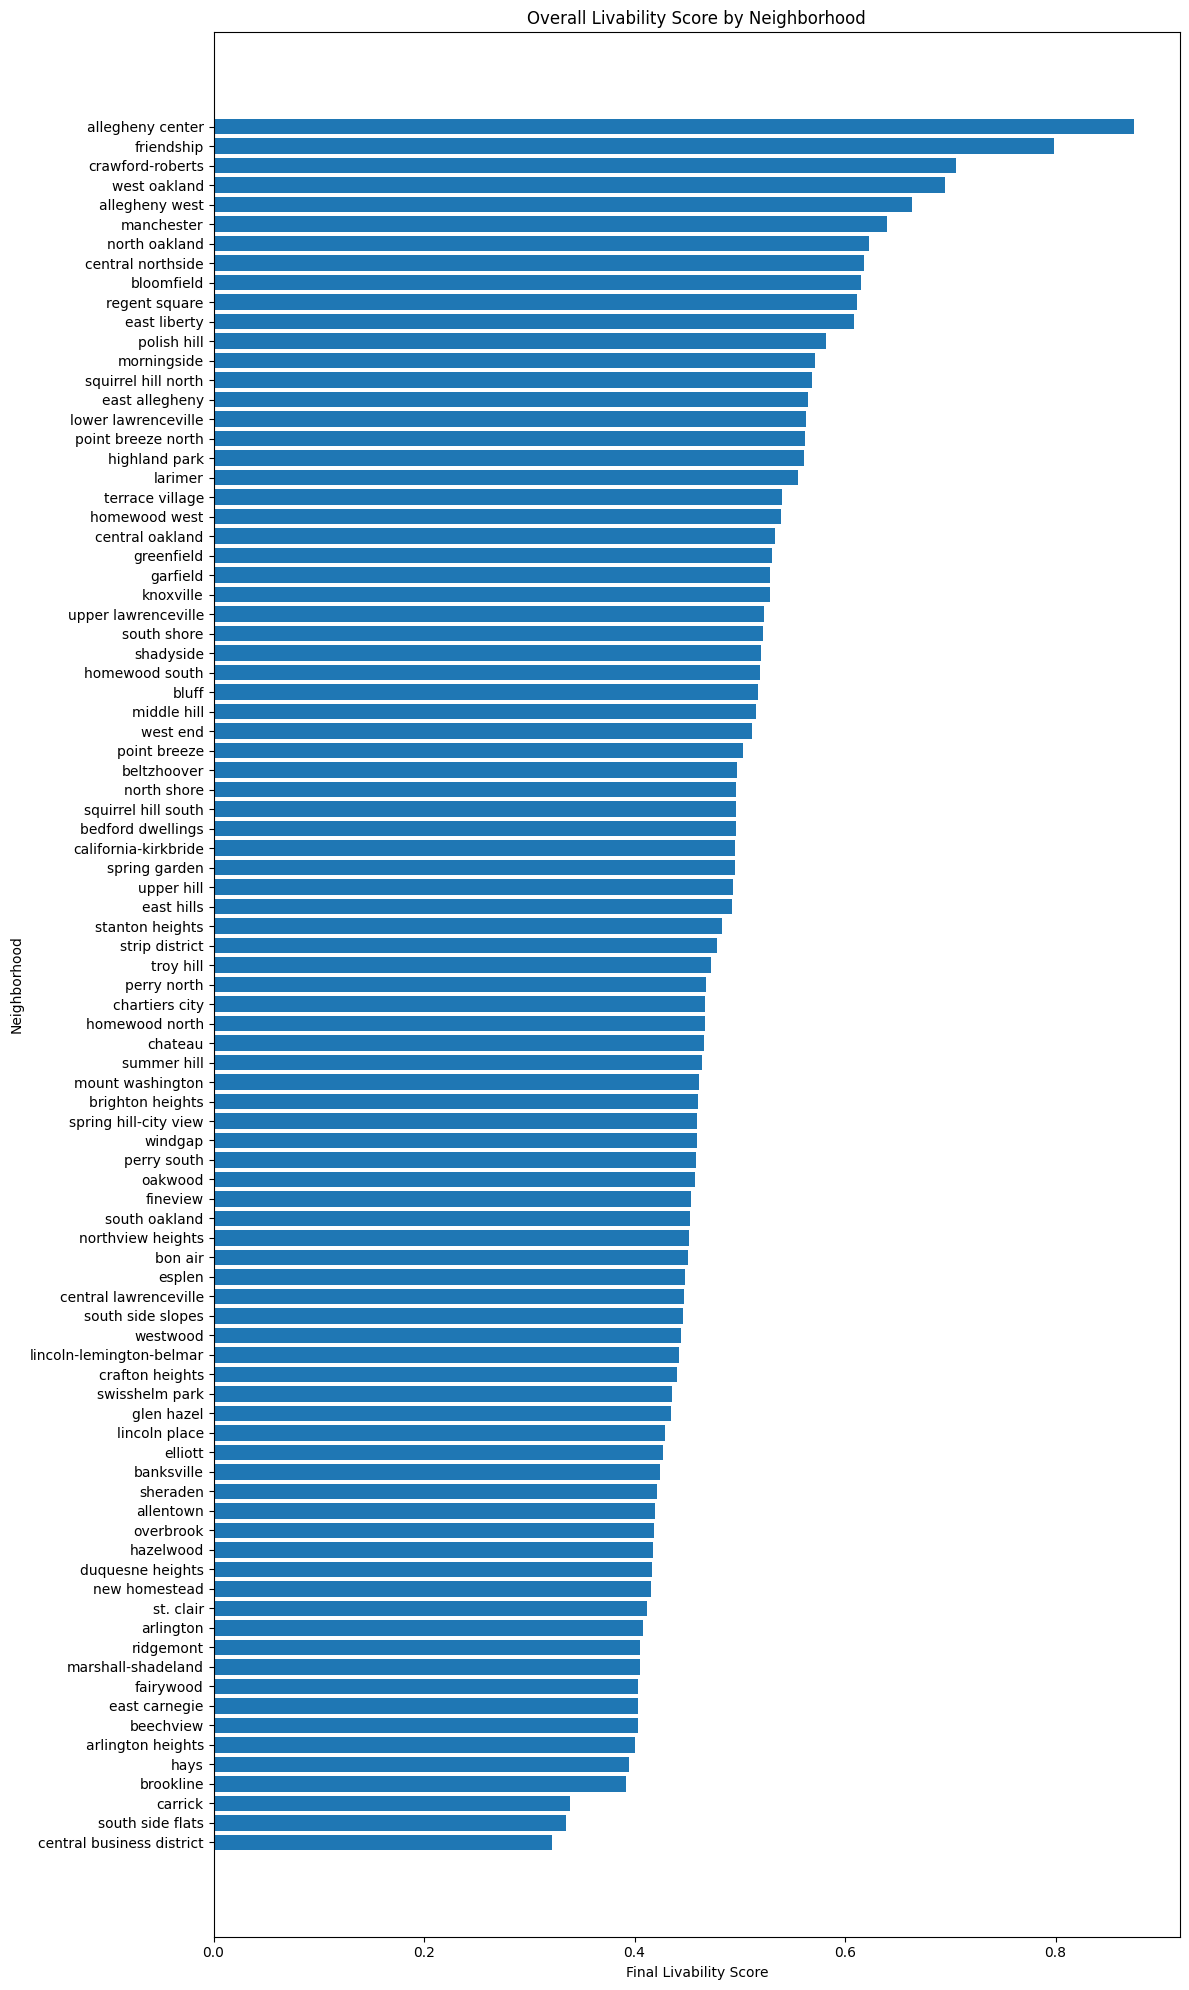

In [32]:
plt.figure(figsize=(12, 20))

plt.barh(final_ranked['neighborhood'], final_ranked['final_score'])

plt.gca().invert_yaxis()

plt.xlabel("Final Livability Score")
plt.ylabel("Neighborhood")
plt.title("Overall Livability Score by Neighborhood")

plt.tight_layout()
plt.show()

## 3. conclusion

we can see from the figure that **allgheny center** has the highest score, so we can conlude that in our analysis, **allgheny center** is the "best" neighborhood in Pittsburgh accoriding to our final livability score.

# Part4 Project Conclusion

In this project, we tried to evaluate the livability of Pittsburgh neighborhoods using three factors: crime, tree density, and transit convenience. Since these metrics have different scales, we first group them with an ascending order. After we get the results, we normalized all of them to values between 0 and 1. Then we combined them into one final score using a weighted formula, where crime was given a higher weight (0.4), and tree density and convenience were each given 0.3.From the results, we can see that some neighborhoods like Allegheny Center and Friendship rank at the top. This means they have a good balance between safety, environmental quality, and accessibility. On the other hand, neighborhoods with lower scores usually perform worse in at least one of these aspects.In conclusion, this method provides a simple way to compare neighborhoods using multiple factors. Even though the model is not perfect and depends on the weights we pre-defined, it still gives a reasonable idea of which areas are more livable.** 